<a href="https://colab.research.google.com/github/Nidhisha00/AIML-10days-Internship/blob/main/Day5/NLP_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Loading of  Dataset

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

# Extract dataset
zip_path = "/content/archive (2).zip"      # Upload your ZIP file to Colab
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

# Collect CSV file paths
csv_paths = glob(os.path.join(extract_path, '**', '*.csv'), recursive=True)

print("Total CSV Files:", len(csv_paths))

if len(csv_paths) == 0:
    raise FileNotFoundError("No CSV file found inside the ZIP file.")

# Load the first CSV file found
csv_path = csv_paths[0]

print("CSV File Found:", csv_path)

# Convert CSV into DataFrame
data = pd.read_csv(csv_path)

print("\nDataset Loaded Successfully")
print("Dataset Shape:", data.shape)

# Display first 5 rows
display(data.head())

Dataset Extracted Successfully
Total CSV Files: 1
CSV File Found: /content/dataset/healthcare_dataset.csv

Dataset Loaded Successfully
Dataset Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
df=pd.read_csv('/content/dataset/healthcare_dataset.csv')

packages of nlp


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

stopward removal

In [ ]:
stop_words=set(stopwords.words('english'))
print(stop_words)
lemmatizer=WordNetLemmatizer()

{"doesn't", "we've", "you're", 'out', 'during', 'she', 'myself', 'has', 'shouldn', "you'll", 'him', "aren't", 'our', 'ain', 'before', "we'd", 'wouldn', "weren't", 'because', "haven't", 'hers', 'not', 'should', 'be', 'it', "it'll", 'they', 'there', 'too', "they're", 'few', "he'd", 'here', 'herself', 'into', 'own', 'didn', 'in', "couldn't", 'doing', 'off', 'haven', 'each', 'themselves', 'the', 'those', 'very', 'wasn', 'will', "they've", "mightn't", 'more', 'that', 'both', 've', 'to', 'their', 'don', 'aren', 'yourselves', 'shan', 'me', "i've", 'where', "you'd", "shan't", 'an', 'whom', 'you', "he'll", "she's", "won't", 'y', 'your', 'further', 'does', 'a', 'up', 'nor', 'after', 'all', 'which', 'then', "needn't", 're', 'ourselves', 'are', "they'd", 'who', 'yours', "you've", 'through', 'above', 'had', 'isn', 'he', "he's", "she'll", 'won', 'his', 'have', 'this', 'was', 'so', 'its', 'hasn', "i'd", 'between', 'i', 'do', 'll', 'and', 'about', 'ma', 'when', 'did', 'once', 'just', 'mustn', "that'll

Tokenization

In [ ]:
def process_text(text):
  word_tokens=word_tokenize(text)
  filtered_tokens=[word for word in word_tokens if word.casefold() not in stop_words]
  lemmatized_tokens=[lemmatizer.lemmatize(word.lower()) for word in filtered_tokens]
  return {
      "original_text":text,
      "word_tokens":word_tokens,
      "filtered_tokens":filtered_tokens,
      "lemmatized_tokens":lemmatized_tokens
  }


Setting up of essential components oftext preprocessing

In [ ]:
results=df['Medical Condition'].apply(process_text)
processed_df=pd.DataFrame(results.tolist())
print(processed_df.head())
processed_file_path="processed_nlp_dataset.csv"
processed_df.to_csv(processed_file_path,index=False)

  original_text word_tokens filtered_tokens lemmatized_tokens
0        Cancer    [Cancer]        [Cancer]          [cancer]
1       Obesity   [Obesity]       [Obesity]         [obesity]
2       Obesity   [Obesity]       [Obesity]         [obesity]
3      Diabetes  [Diabetes]      [Diabetes]        [diabetes]
4        Cancer    [Cancer]        [Cancer]          [cancer]


In [ ]:
print(results.head())

0    {'original_text': 'Cancer', 'word_tokens': ['C...
1    {'original_text': 'Obesity', 'word_tokens': ['...
2    {'original_text': 'Obesity', 'word_tokens': ['...
3    {'original_text': 'Diabetes', 'word_tokens': [...
4    {'original_text': 'Cancer', 'word_tokens': ['C...
Name: Medical Condition, dtype: object


In [ ]:
print(processed_df)

      original_text     word_tokens filtered_tokens lemmatized_tokens
0            Cancer        [Cancer]        [Cancer]          [cancer]
1           Obesity       [Obesity]       [Obesity]         [obesity]
2           Obesity       [Obesity]       [Obesity]         [obesity]
3          Diabetes      [Diabetes]      [Diabetes]        [diabetes]
4            Cancer        [Cancer]        [Cancer]          [cancer]
...             ...             ...             ...               ...
55495        Asthma        [Asthma]        [Asthma]          [asthma]
55496       Obesity       [Obesity]       [Obesity]         [obesity]
55497  Hypertension  [Hypertension]  [Hypertension]    [hypertension]
55498     Arthritis     [Arthritis]     [Arthritis]       [arthritis]
55499     Arthritis     [Arthritis]     [Arthritis]       [arthritis]

[55500 rows x 4 columns]


In [22]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Load the dataset
data = pd.read_csv('/content/dataset/healthcare_dataset.csv')

# Select the text column for Bag of Words
text_data = data['Medical Condition'].astype(str)

# Create Bag of Words representation
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(text_data)

# Convert to DataFrame
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Display the first few rows
print("Bag of Words Representation:")
print(bow_df.head())

# Save the BoW representation as a CSV file
bow_df.to_csv('/content/bag_of_words.csv', index=False)

print("\nBag of Words saved as '/content/bag_of_words.csv'.")
print("Shape of Bag of Words matrix:", bow_df.shape)

Bag of Words Representation:
   arthritis  asthma  cancer  diabetes  hypertension  obesity
0          0       0       1         0             0        0
1          0       0       0         0             0        1
2          0       0       0         0             0        1
3          0       0       0         1             0        0
4          0       0       1         0             0        0

Bag of Words saved as '/content/bag_of_words.csv'.
Shape of Bag of Words matrix: (55500, 6)


In [23]:
from wordcloud  import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

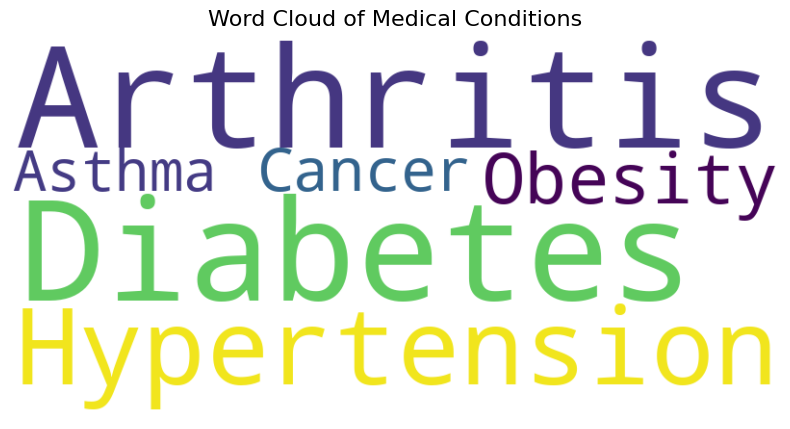

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load the dataset
data = pd.read_csv('/content/dataset/healthcare_dataset.csv')

# Combine all text from the Medical Condition column
text_data = " ".join(data['Medical Condition'].dropna().astype(str))

# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_data)

# Display Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Medical Conditions", fontsize=16)
plt.show()